<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Support_Vector_Machine/RBF_SVM_using_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RBF Kernel SVM on Two Moons Dataset

A nonlinear Support Vector Machine using the Radial Basis Function (RBF) Kernel to classify the Two Moons dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
X, Y = make_moons(
    n_samples=300,
    noise=0.15,
    random_state=42
)

## Dataset

The Two Moons dataset contains two interleaving classes that require a nonlinear decision boundary.

The dataset cannot be separated by a single straight line.


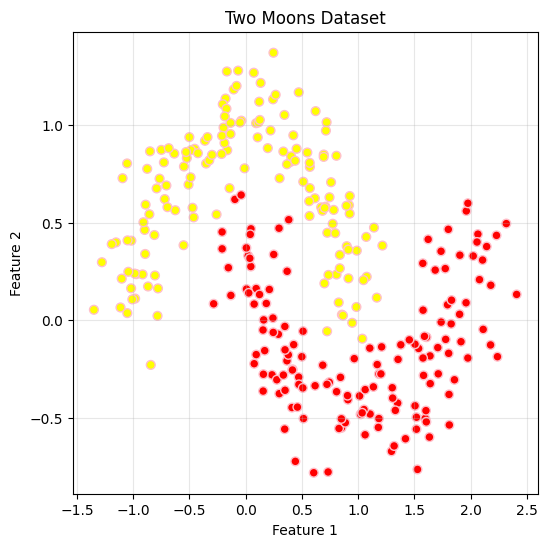

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=Y,
    cmap="autumn_r",
    edgecolors="pink",
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Moons Dataset")
plt.grid(alpha=0.3)
plt.show()

## Data Preprocessing

`StandardScaler` standardizes both features so they contribute equally to the distance calculations used by the RBF kernel.

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## RBF Kernel

The Radial Basis Function (Gaussian) Kernel measures similarity based on distance.

<math value="K(x,z)=e^{-\\gamma\\|x-z\\|^2}" block/>

Instead of creating polynomial features, each training point creates a region of influence around itself.

In [7]:
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(X_train, Y_train)

SVC(C=1)

In [8]:
train_pred = rbf_svm.predict(X_train)
test_pred = rbf_svm.predict(X_test)

In [9]:
train_accuracy = accuracy_score(Y_train, train_pred)
test_accuracy = accuracy_score(Y_test, test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9708
Test Accuracy: 0.9667


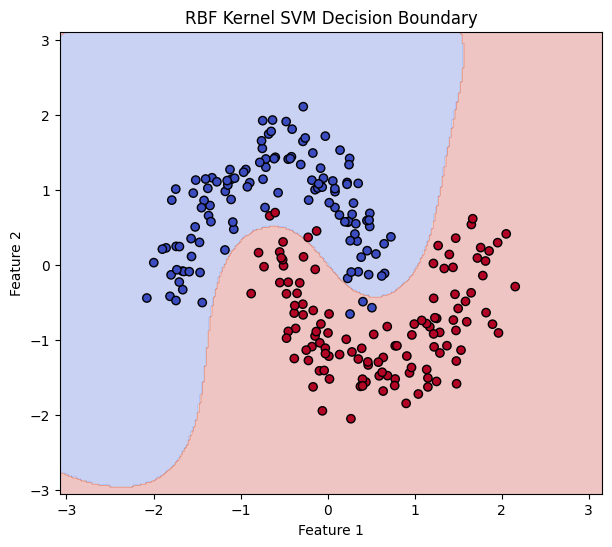

In [10]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = rbf_svm.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=Y_train,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("RBF Kernel SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Observations

- RBF learns smooth nonlinear decision boundaries.
- Nearby points have stronger influence than distant points.
- `gamma` controls how quickly influence decreases with distance.
- Standardization is important because the kernel depends on Euclidean distance.

## Effect of Gamma

`gamma` controls how far each training point influences the decision boundary.

| Gamma | Test Accuracy |
|------:|-------------:|
| **0.1** | **80.00%** |
| **1** | **98.33%** |
| **10** | **96.67%** |

For this dataset, **gamma = 1** produced the best test accuracy by balancing flexibility and generalization.

In [11]:
for g in [0.1, 1, 10]:
    model = SVC(kernel="rbf", gamma=g, C=1)
    model.fit(X_train, Y_train)
    score = model.score(X_test, Y_test)
    print(f"Gamma={g}: {score:.4f}")


Gamma=0.1: 0.8000
Gamma=1: 0.9833
Gamma=10: 0.9667


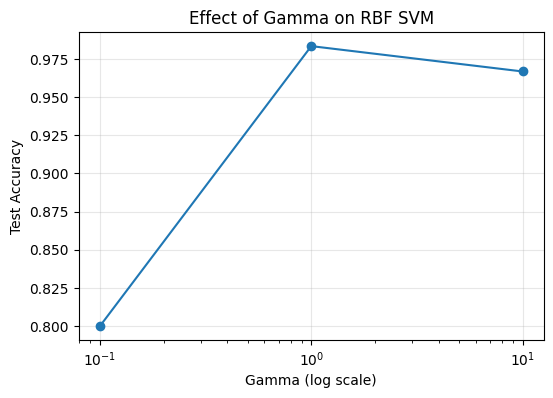

In [12]:
gammas = [0.1, 1, 10]
accuracies = [0.80, 0.9833, 0.9667]

plt.figure(figsize=(6,4))
plt.plot(gammas, accuracies, marker="o")
plt.xscale("log")
plt.xlabel("Gamma (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Gamma on RBF SVM")
plt.grid(alpha=0.3)
plt.show()


## Conclusion

The RBF Kernel SVM successfully separates the Two Moons dataset by using distance-based similarity instead of explicitly creating new features.